<a href="https://colab.research.google.com/github/FadhilTaufiqurrachman/Machine-Learning/blob/main/244107020090_Fadhil_Taufiqurrachman_T5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Praktikum Jobsheet 5

NIM : 244107020090

Nama : Fadhil Taufiqurrachman

Kelas : TI 3G

No Absen : 06

Mata Kuliah : Pembelajaran Mesin

In [ ]:
!pip install hdbscan

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import hdbscan
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score

In [ ]:
# ---------------------------------------------------------
# 1. Pilih Dataset
# ---------------------------------------------------------
print("1. Memuat Digits Dataset...")
digits = load_digits()
X = digits.data
y_true = digits.target # Label asli (ground truth)
print(f"   -> Bentuk data: {X.shape} (1797 sampel, 64 dimensi)\n")

1. Memuat Digits Dataset...
   -> Bentuk data: (1797, 64) (1797 sampel, 64 dimensi)



In [ ]:
# ---------------------------------------------------------
# 2. Lakukan Clustering dengan HDBSCAN
# ---------------------------------------------------------
print("2. Menjalankan algoritma HDBSCAN...")
# min_cluster_size: Jumlah minimum titik data untuk membentuk sebuah cluster
# min_samples: Mengontrol seberapa konservatif clustering (semakin besar, semakin banyak noise)
clusterer = hdbscan.HDBSCAN(min_cluster_size=20, min_samples=10)
cluster_labels = clusterer.fit_predict(X)

2. Menjalankan algoritma HDBSCAN...


3. Laporan Hasil Clustering:
   -> Jumlah cluster yang terbentuk : 10
   -> Banyaknya noise               : 816 dari total 1797 data

   -> Memproses reduksi dimensi dengan t-SNE (mohon tunggu sebentar)...


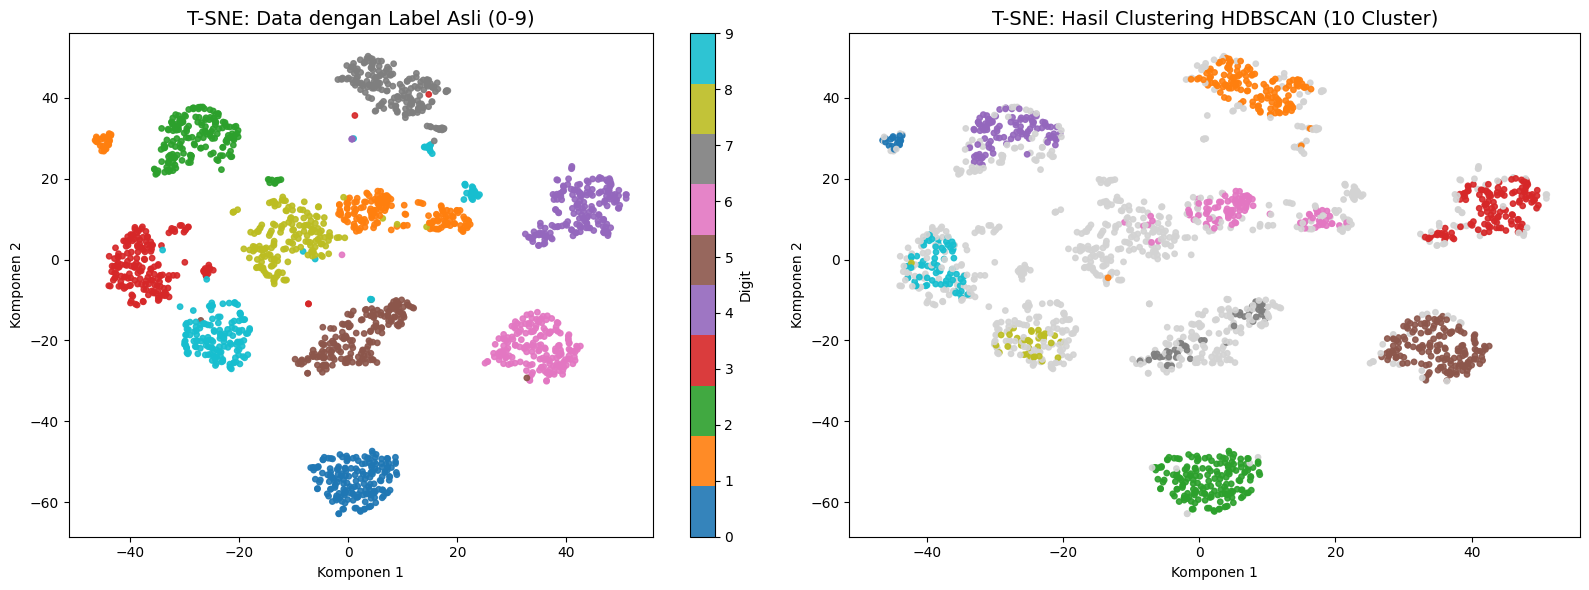

In [ ]:
# ---------------------------------------------------------
# 3. Laporkan Hasil
# ---------------------------------------------------------
# Label -1 dalam HDBSCAN menandakan data tersebut adalah noise/outlier
jumlah_cluster = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
banyaknya_noise = list(cluster_labels).count(-1)

print("3. Laporan Hasil Clustering:")
print(f"   -> Jumlah cluster yang terbentuk : {jumlah_cluster}")
print(f"   -> Banyaknya noise               : {banyaknya_noise} dari total {len(X)} data\n")

# --- Visualisasi dengan t-SNE ---
print("   -> Memproses reduksi dimensi dengan t-SNE (mohon tunggu sebentar)...")
# Kita menggunakan t-SNE karena jauh lebih baik dari PCA dalam
# mempertahankan struktur lokal data berdimensi tinggi (64 dimensi -> 2 dimensi)
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X)

# Mengatur tata letak visualisasi (1 baris, 2 kolom)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Visualisasi berdasarkan Label Asli (Ground Truth)
scatter_asli = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_true, cmap='tab10', s=15, alpha=0.9)
axes[0].set_title('T-SNE: Data dengan Label Asli (0-9)', fontsize=14)
axes[0].set_xlabel('Komponen 1')
axes[0].set_ylabel('Komponen 2')
fig.colorbar(scatter_asli, ax=axes[0], ticks=range(10), label='Digit')

# Plot 2: Visualisasi berdasarkan Hasil HDBSCAN
# Kita buat warna kustom: Warna Abu-abu terang untuk noise (-1)
warna_hdbscan = ['#d3d3d3' if label == -1 else plt.cm.tab10(label % 10) for label in cluster_labels]
axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=warna_hdbscan, s=15, alpha=0.9)
axes[1].set_title(f'T-SNE: Hasil Clustering HDBSCAN ({jumlah_cluster} Cluster)', fontsize=14)
axes[1].set_xlabel('Komponen 1')
axes[1].set_ylabel('Komponen 2')

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# 4. Analisis Tambahan (Evaluasi Metrik)
# ---------------------------------------------------------
# Menggunakan Adjusted Rand Index untuk membandingkan kecocokan label asli vs cluster
ari_score = adjusted_rand_score(y_true, cluster_labels)
print(f"\nSkor Adjusted Rand Index (ARI): {ari_score:.3f}")
print("(Skor mendekati 1.0 menunjukkan hasil cluster sangat selaras dengan label asli)")


Skor Adjusted Rand Index (ARI): 0.279
(Skor mendekati 1.0 menunjukkan hasil cluster sangat selaras dengan label asli)


Analisis : Berdasarkan visualisasi dan metrik evaluasi, hasil clustering HDBSCAN tidak sepenuhnya sesuai dengan label asli dataset. Meskipun algoritma ini berhasil membentuk 10 klaster yang sejalan dengan jumlah kelompok digit aslinya, skor Adjusted Rand Index (ARI) yang dihasilkan cukup rendah, yaitu 0.279. Ketidaksesuaian ini utamanya disebabkan oleh karakteristik HDBSCAN yang mengelompokkan data berdasarkan kerapatan (density-based), sehingga sebanyak 816 data (sekitar 45%) dianggap sebagai noise karena variasi tulisan tangannya terlalu ekstrem atau letaknya tidak cukup rapat dengan kelompok utama. Berbeda dengan label asli yang secara mutlak memasukkan setiap gambar ke sebuah kelas angka, HDBSCAN membiarkan data-data ambigu tersebut berada di luar klaster, sehingga strukturnya menjadi berbeda dengan ground truth.